<a href="https://colab.research.google.com/github/Rayudu-Somisetty/deep_learning_lab_tasks/blob/main/XOR_gate_using_parameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial Parameters:
W1:
 [[-0.25091976  0.90142861]
 [ 0.46398788  0.19731697]]
b1: [[0. 0.]]
W2:
 [[-0.68796272]
 [-0.68801096]]
b2: [[0.]]

Training 2-Layer Neural Network for XOR...

Iteration    0 | Loss = 0.500546
Iteration 10000 | Loss = 0.098431
Iteration 20000 | Loss = 0.045364
Iteration 30000 | Loss = 0.033334
Iteration 40000 | Loss = 0.027469

Training Complete!
Final Loss: 0.023857

Final Predictions:
--------------------------------------------------
Input [0 0] → Pred: 0.0230 (Class 0) | Actual: 0 ✓
Input [0 1] → Pred: 0.9742 (Class 1) | Actual: 1 ✓
Input [1 0] → Pred: 0.9742 (Class 1) | Actual: 1 ✓
Input [1 1] → Pred: 0.0208 (Class 0) | Actual: 0 ✓

Decision Boundary Analysis:
--------------------------------------------------
Final W1:
[[-6.51553687  6.6985006 ]
 [ 6.70952951 -6.49332069]]
Final b1: [[3.30011836 3.28535502]]
Final W2:
[[-8.29287363]
 [-8.29495091]]
Final b2: [[12.24575797]]


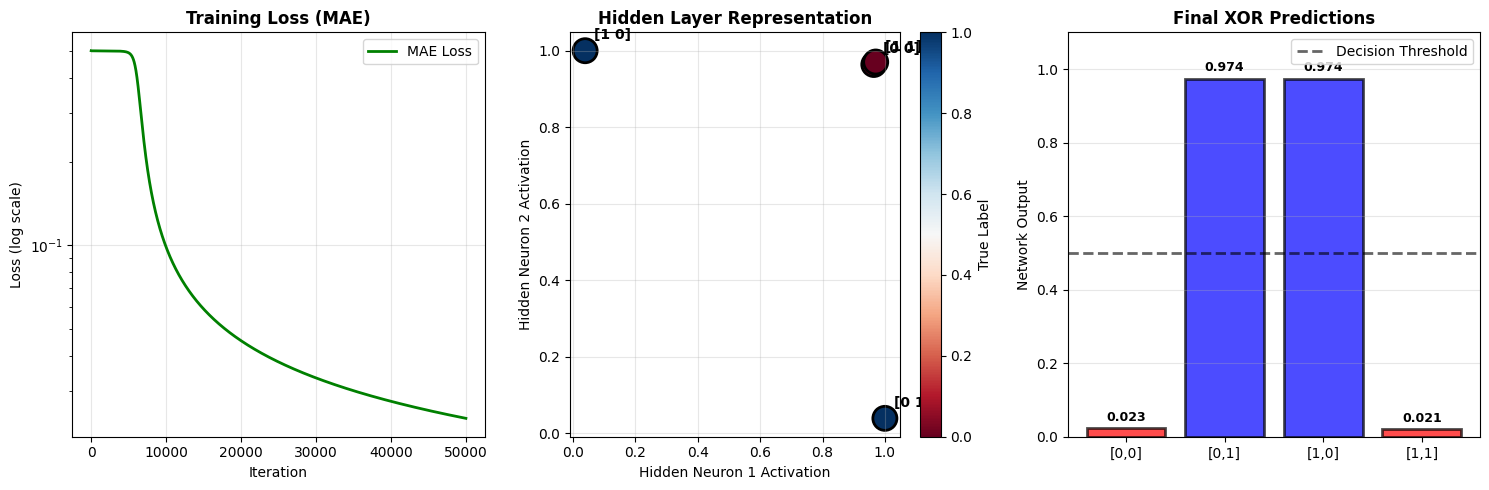


Accuracy: 100.00%


In [4]:
#XOR gate using parameters
import numpy as np
import matplotlib.pyplot as plt


# Hyperparameters

input_size = 2
hidden_size = 2      # Minimum needed for XOR
output_size = 1
learning_rate = 0.1  # Reduced from 0.1 for stability
iterations = 50000
print_interval = 10000


# XOR Dataset

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])
y = np.array([
    [0],
    [1],
    [1],
    [0]
])

# Random Initialization (CORRECTED)

np.random.seed(42)  # Reproducible randomness (FIXED)

# Weights: random uniform [-1, 1]
W1 = np.random.uniform(-1, 1, (input_size, hidden_size))
W2 = np.random.uniform(-1, 1, (hidden_size, output_size))

# Biases: start at ZERO (FIXED)
b1 = np.zeros((1, hidden_size))
b2 = np.zeros((1, output_size))

print("Initial Parameters:")
print("W1:\n", W1)
print("b1:", b1)
print("W2:\n", W2)
print("b2:", b2)


# Activation Functions

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

def sigmoid_derivative(a):
    return a * (1 - a)


# Helper Function for Inference

def forward_pass(X, W1, b1, W2, b2):
    """Performs forward pass and returns output and hidden activation"""
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    output = sigmoid(z2)
    return output, a1, z1, z2

# Training Loop

loss_history = []

print("\nTraining 2-Layer Neural Network for XOR...\n")

for i in range(iterations):
    # ---------- Forward Pass ----------
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, W2) + b2
    output = sigmoid(z2)

    # ---------- Loss Calculation ----------
    error = y - output
    loss = np.mean(np.abs(error))
    loss_history.append(loss)

    # ---------- Backpropagation ----------
    # Output layer gradient
    d_output = error * sigmoid_derivative(output)

    # Hidden layer gradient (chain rule)
    d_hidden = np.dot(d_output, W2.T) * sigmoid_derivative(a1)

    # ---------- Gradient Descent - Update Weights & Biases ----------
    # Output layer updates
    W2 += learning_rate * np.dot(a1.T, d_output)
    b2 += learning_rate * np.sum(d_output, axis=0, keepdims=True)

    # Hidden layer updates
    W1 += learning_rate * np.dot(X.T, d_hidden)
    b1 += learning_rate * np.sum(d_hidden, axis=0, keepdims=True)

    if i % print_interval == 0:
        print(f"Iteration {i:4d} | Loss = {loss:.6f}")

print("\nTraining Complete!")
print(f"Final Loss: {loss_history[-1]:.6f}")


# Final Predictions (CORRECTED - Separate Inference)

final_output, final_a1, _, _ = forward_pass(X, W1, b1, W2, b2)

print("\nFinal Predictions:")
print("-" * 50)
for i in range(len(X)):
    cls = 1 if final_output[i, 0] > 0.5 else 0
    actual = int(y[i, 0])
    match = "✓" if cls == actual else "✗"
    print(f"Input {X[i]} → Pred: {final_output[i,0]:.4f} (Class {cls}) | Actual: {actual} {match}")


# Decision Boundary Analysis

print("\nDecision Boundary Analysis:")
print("-" * 50)
print(f"Final W1:\n{W1}")
print(f"Final b1: {b1}")
print(f"Final W2:\n{W2}")
print(f"Final b2: {b2}")


# Visualization

plt.figure(figsize=(15, 5))

# Plot 1: Loss Curve
plt.subplot(1, 3, 1)
plt.semilogy(loss_history, 'g', linewidth=2, label='MAE Loss')
plt.title("Training Loss (MAE)", fontsize=12, fontweight='bold')
plt.xlabel("Iteration")
plt.ylabel("Loss (log scale)")
plt.grid(alpha=0.3)
plt.legend()

# Plot 2: Hidden Layer Activations
plt.subplot(1, 3, 2)
scatter = plt.scatter(final_a1[:, 0], final_a1[:, 1],
                      c=y.flatten(), cmap='RdBu',
                      s=300, edgecolors='black', linewidth=2)

for i in range(len(X)):
    plt.text(final_a1[i,0]+0.03, final_a1[i,1]+0.03,
             f"{X[i]}", fontsize=10, fontweight='bold')

plt.xlabel("Hidden Neuron 1 Activation")
plt.ylabel("Hidden Neuron 2 Activation")
plt.title("Hidden Layer Representation", fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
cbar = plt.colorbar(scatter)
cbar.set_label('True Label')

# Plot 3: Output Predictions
plt.subplot(1, 3, 3)
colors = ['red' if v < 0.5 else 'blue' for v in final_output.flatten()]
bars = plt.bar(range(4), final_output.flatten(),
               color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, final_output.flatten())):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.axhline(0.5, linestyle='--', color='black', alpha=0.6, linewidth=2, label='Decision Threshold')
plt.xticks(range(4), ['[0,0]', '[0,1]', '[1,0]', '[1,1]'])
plt.ylabel("Network Output")
plt.title("Final XOR Predictions", fontsize=12, fontweight='bold')
plt.ylim([0, 1.1])
plt.legend()
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Accuracy Calculation

predictions = (final_output > 0.5).astype(int)
accuracy = np.mean(predictions == y) * 100
print(f"\nAccuracy: {accuracy:.2f}%")
